In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option("display.max_columns", None)

In [ ]:
sns.set_style("whitegrid")

In [ ]:
df=pd.read_csv("/content/german_credit_data.csv")

In [ ]:
df.head()

In [ ]:
df.describe()

In [ ]:
df["Risk"].value_counts()

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df["Job"].unique()

In [ ]:
df.isna().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df.dropna().reset_index(drop=True)

In [ ]:
df.drop(columns= 'Unnamed: 0', inplace= True)
#By using inplace=True, you instruct Pandas to: Update the existing object: The changes are applied to the variable itself in memory.

In [ ]:
df.head()

In [ ]:
df[["Age","Credit amount","Duration"]].hist(bins=20, edgecolor="black")
#bins means how many groups the data is segregated in
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

In [ ]:
plt.figure(figsize= ( 10,5))
for i, col in enumerate (["Age","Credit amount","Duration"]):
  plt.subplot(1,3,i+1)
  sns.boxplot(y=df[col], color="skyblue")
  plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
df.query("Duration >= 60")

In [ ]:
categorical_cols=["Sex","Job","Housing","Saving accounts","Checking account","Purpose"]

In [ ]:
plt.figure(figsize= (10,10))
for i, col in enumerate(categorical_cols):
  plt.subplot(3,3,i+1)
  sns.countplot(data=df, x=col, palette="Set2", order= df[col].value_counts().index)
  plt.title(f"Distribution of {col}")
  plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
corr= df[["Age","Job","Credit amount","Duration"]].corr()

In [ ]:
corr

In [ ]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [ ]:
df.groupby("Job")["Credit amount"].mean()

In [ ]:
df.groupby("Sex")["Credit amount"].mean()

In [ ]:
pd.pivot_table(df,values="Credit amount", index= "Housing", columns= "Purpose")

In [ ]:
sns.scatterplot(data=df,x="Age", y="Credit amount", hue="Sex", size="Duration", alpha= 0.7, palette= "Set1")
plt.title("Credit amount vs Age coloured by Sex and sized by Duration")
plt.show()

In [ ]:
sns.violinplot(data= df, x= "Saving accounts", y= "Credit amount", palette= "Pastel1")
plt.title("Credit Amount Distribution by Saving Accounts")
plt.show()

In [ ]:
df["Risk"].value_counts(normalize=True)*100

In [ ]:
plt.figure(figsize=(15,4))
for i, col in enumerate(["Age","Credit amount","Duration"]):
  plt.subplot(1,3, i+1)
  sns.boxplot(data=df,x="Risk", y= col, palette= "Pastel2")
  plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [ ]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].mean()

In [ ]:
categorical_cols

In [ ]:
plt.figure(figsize=(15,10))
for i, col in enumerate(categorical_cols):
  plt.subplot(3,3, i+1)
  sns.countplot(data=df, x= col, hue="Risk", palette= "Set1", order = df[col].value_counts().index)
  plt.title(f"{col} by Risk")
  plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
df.columns

In [ ]:
features= ["Age", "Sex","Job","Housing","Saving accounts","Checking account","Credit amount","Duration"]

In [ ]:
target= "Risk"

In [ ]:
df_model=df[features + [target]].copy()

In [ ]:
df_model.head()

In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [ ]:
cat_cols= df_model.select_dtypes(include="object").columns.drop("Risk")

In [ ]:
le_dict={}

In [ ]:
cat_cols

In [ ]:
for col in cat_cols:
  le= LabelEncoder()
  df_model[col]= le.fit_transform(df_model[col])
  le_dict[col]= le
  joblib.dump(le, f"{col}_encoder.pkl")

In [79]:
le_target= LabelEncoder()
df_model[target]= le_target.fit_transform(df_model[target])

In [ ]:
target

In [ ]:
df_model[target]

In [ ]:
df_model[target].value_counts()

In [ ]:
joblib.dump(le_target, "target_encoder.pkl")

In [ ]:
df_model.head()

In [ ]:
from sklearn.model_selection import train_test_split

In [82]:
X=df_model.drop(target, axis=1)

In [83]:
y=df_model[target]

In [ ]:
X

In [ ]:
y

In [84]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

In [ ]:
X_train.shape

In [ ]:
X_test.shape

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [ ]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
  grid= GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
  grid.fit(X_train, y_train)
  best_model= grid.best_estimator_
  y_pred= best_model.predict(X_test)
  acc= accuracy_score(y_test, y_pred)
  return best_model, acc, grid.best_params_

In [ ]:
dt = DecisionTreeClassifier(random_state=1, class_weight="balanced")
dt_param_grid = {
    'max_depth': [3,5,7,10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
best_dt, acc_dt, params_dt= train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [ ]:
print("Decision Tree Accuracy", acc_dt)

In [ ]:
print("Best parameters", params_dt)

In [ ]:
rf= RandomForestClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [ ]:
rf_param_grid={
    "n_estimators": [100,200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1,2,4]
}

In [ ]:
best_rf, acc_rf, params_rf= train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [ ]:
print("Random Forest Accuracy", acc_rf)

In [ ]:
print("Best params", params_rf)

In [ ]:
et= ExtraTreesClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [ ]:
et_param_grid={
    "n_estimators": [100,200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1,2,4]
}

In [73]:
best_et, acc_et, params_et= train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [74]:
print("Extra trees accuracy", acc_et)

Extra trees accuracy 0.755


In [86]:
xgb= XGBClassifier(random_state=1, scale_pos_weight= (y_train ==1).sum(), use_label_encoder= False, eval_metric= "logloss")

In [87]:
xgb_param_grid={
    "n_estimators": [100,200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1],
    "colsample_bytree": [0.7, 1]
}

In [88]:
best_xgb, acc_xgb, params_xgb= train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [20:41:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [89]:
print("XGB accuracy", acc_xgb)

XGB accuracy 0.725


In [92]:
print("Best params", params_xgb)

Best params {'colsample_bytree': 1, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}


In [91]:
best_et.predict(X_test)

array(['good', 'good', 'good', 'good', 'bad', 'good', 'good', 'good',
       'good', 'good', 'bad', 'good', 'good', 'good', 'bad', 'good',
       'good', 'good', 'good', 'bad', 'good', 'bad', 'good', 'good',
       'good', 'good', 'good', 'good', 'good', 'good', 'good', 'good',
       'good', 'good', 'good', 'good', 'bad', 'good', 'good', 'good',
       'good', 'bad', 'good', 'good', 'good', 'good', 'good', 'bad',
       'good', 'good', 'good', 'good', 'bad', 'good', 'bad', 'bad', 'bad',
       'good', 'good', 'good', 'good', 'good', 'good', 'good', 'good',
       'good', 'good', 'good', 'bad', 'good', 'bad', 'bad', 'good',
       'good', 'good', 'good', 'good', 'good', 'good', 'good', 'good',
       'bad', 'bad', 'good', 'bad', 'good', 'good', 'good', 'good',
       'good', 'good', 'good', 'good', 'good', 'good', 'good', 'good',
       'bad', 'good', 'bad', 'bad', 'good', 'bad', 'good', 'good', 'bad',
       'good', 'good', 'good', 'bad', 'good', 'good', 'bad', 'good',
       'good', 

In [93]:
joblib.dump(best_et, "extra_trees_credit_model.pkl")

['extra_trees_credit_model.pkl']

In [94]:
from sklearn.metrics import classification_report, confusion_matrix

### Decision Tree Classifier Performance

In [99]:
y_pred_dt = best_dt.predict(X_test)
print(f"Raw DT predictions (first 5): {y_pred_dt[:5]}, dtype: {y_pred_dt.dtype}")
y_pred_dt_numeric = le_target.transform(y_pred_dt)
print(f"Numeric DT predictions (first 5): {y_pred_dt_numeric[:5]}, dtype: {y_pred_dt_numeric.dtype}")
print("Classification Report for Decision Tree:\n", classification_report(y_test, y_pred_dt_numeric))
print("Confusion Matrix for Decision Tree:\n", confusion_matrix(y_test, y_pred_dt_numeric))

Raw DT predictions (first 5): ['good' 'good' 'good' 'good' 'bad'], dtype: object
Numeric DT predictions (first 5): [1 1 1 1 0], dtype: int64
Classification Report for Decision Tree:
               precision    recall  f1-score   support

           0       0.51      0.65      0.57        60
           1       0.83      0.73      0.78       140

    accuracy                           0.70       200
   macro avg       0.67      0.69      0.67       200
weighted avg       0.73      0.70      0.71       200

Confusion Matrix for Decision Tree:
 [[ 39  21]
 [ 38 102]]


### Random Forest Classifier Performance

In [100]:
y_pred_rf = best_rf.predict(X_test)
print(f"Raw RF predictions (first 5): {y_pred_rf[:5]}, dtype: {y_pred_rf.dtype}")
y_pred_rf_numeric = le_target.transform(y_pred_rf)
print(f"Numeric RF predictions (first 5): {y_pred_rf_numeric[:5]}, dtype: {y_pred_rf_numeric.dtype}")
print("Classification Report for Random Forest:\n", classification_report(y_test, y_pred_rf_numeric))
print("Confusion Matrix for Random Forest:\n", confusion_matrix(y_test, y_pred_rf_numeric))

Raw RF predictions (first 5): ['good' 'good' 'good' 'good' 'bad'], dtype: object
Numeric RF predictions (first 5): [1 1 1 1 0], dtype: int64
Classification Report for Random Forest:
               precision    recall  f1-score   support

           0       0.66      0.55      0.60        60
           1       0.82      0.88      0.85       140

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200

Confusion Matrix for Random Forest:
 [[ 33  27]
 [ 17 123]]


### Extra Trees Classifier Performance

In [101]:
y_pred_et = best_et.predict(X_test)
print(f"Raw ET predictions (first 5): {y_pred_et[:5]}, dtype: {y_pred_et.dtype}")
y_pred_et_numeric = le_target.transform(y_pred_et)
print(f"Numeric ET predictions (first 5): {y_pred_et_numeric[:5]}, dtype: {y_pred_et_numeric.dtype}")
print("Classification Report for Extra Trees:\n", classification_report(y_test, y_pred_et_numeric))
print("Confusion Matrix for Extra Trees:\n", confusion_matrix(y_test, y_pred_et_numeric))

Raw ET predictions (first 5): ['good' 'good' 'good' 'good' 'bad'], dtype: object
Numeric ET predictions (first 5): [1 1 1 1 0], dtype: int64
Classification Report for Extra Trees:
               precision    recall  f1-score   support

           0       0.62      0.48      0.54        60
           1       0.80      0.87      0.83       140

    accuracy                           0.76       200
   macro avg       0.71      0.68      0.69       200
weighted avg       0.74      0.76      0.75       200

Confusion Matrix for Extra Trees:
 [[ 29  31]
 [ 18 122]]


### XGBoost Classifier Performance

In [98]:
y_pred_xgb = best_xgb.predict(X_test)
print("Classification Report for XGBoost:\n", classification_report(y_test, y_pred_xgb))
print("Confusion Matrix for XGBoost:\n", confusion_matrix(y_test, y_pred_xgb))

Classification Report for XGBoost:
               precision    recall  f1-score   support

           0       0.65      0.18      0.29        60
           1       0.73      0.96      0.83       140

    accuracy                           0.72       200
   macro avg       0.69      0.57      0.56       200
weighted avg       0.71      0.72      0.67       200

Confusion Matrix for XGBoost:
 [[ 11  49]
 [  6 134]]


### Model Accuracy Comparison

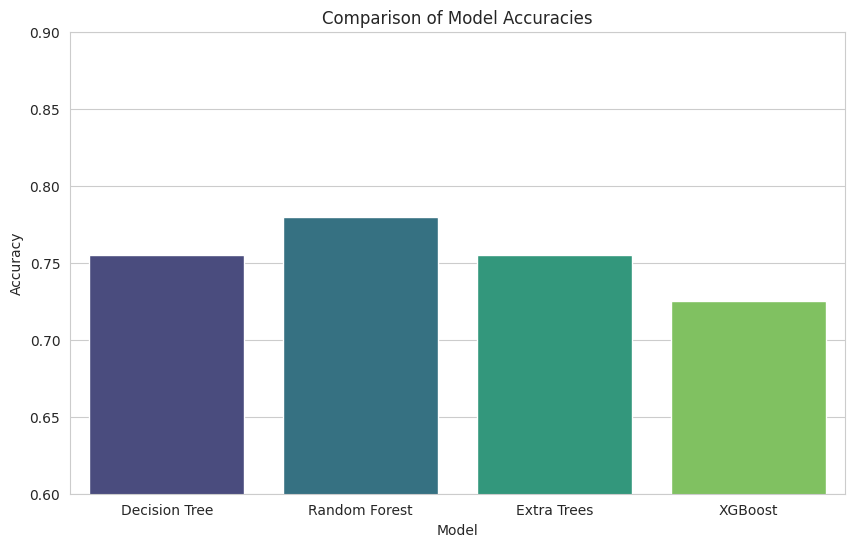

In [103]:
model_accuracies = {
    'Decision Tree': acc_dt,
    'Random Forest': acc_rf,
    'Extra Trees': acc_et,
    'XGBoost': acc_xgb
}

accuracy_df = pd.DataFrame(list(model_accuracies.items()), columns=['Model', 'Accuracy'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=accuracy_df, palette='viridis', legend=False)
plt.title('Comparison of Model Accuracies')
plt.ylabel('Accuracy')
plt.ylim(0.6, 0.9) # Set y-axis limits to focus on the performance range
plt.show()

## Confusion Matrices for All Models

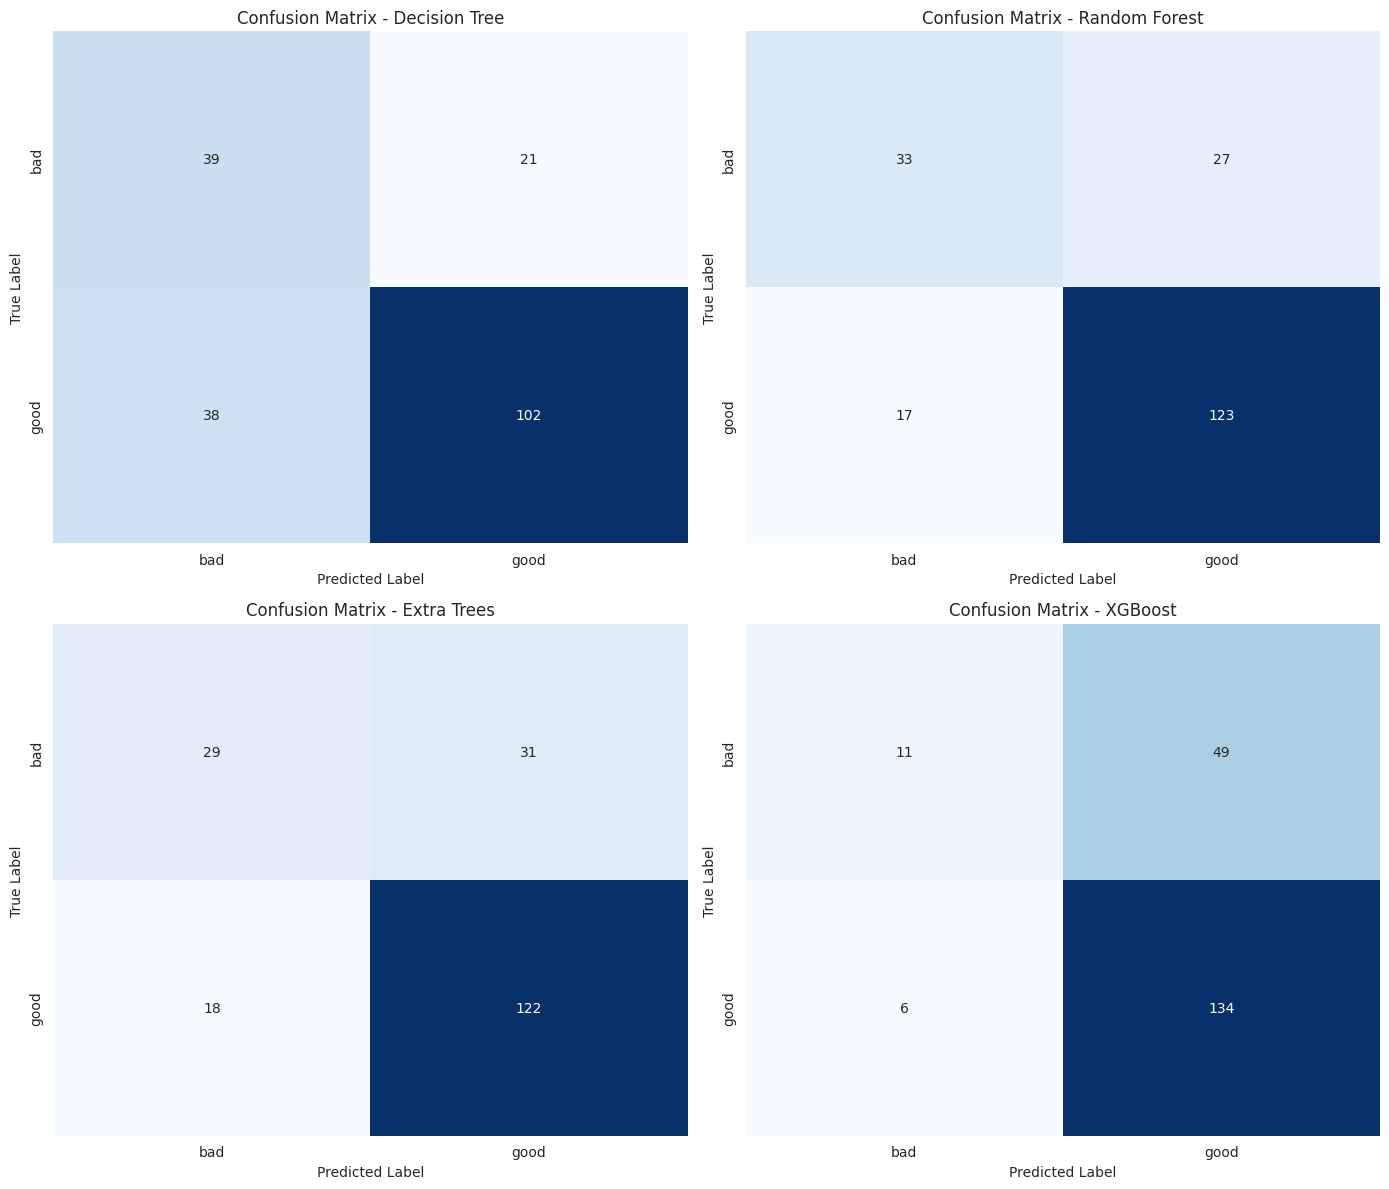

In [105]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions for all models in numeric format
y_pred_dt_numeric = le_target.transform(best_dt.predict(X_test))
y_pred_rf_numeric = le_target.transform(best_rf.predict(X_test))
y_pred_et_numeric = le_target.transform(best_et.predict(X_test))
y_pred_xgb_numeric = best_xgb.predict(X_test)

models = {
    'Decision Tree': y_pred_dt_numeric,
    'Random Forest': y_pred_rf_numeric,
    'Extra Trees': y_pred_et_numeric,
    'XGBoost': y_pred_xgb_numeric
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (model_name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=le_target.classes_, yticklabels=le_target.classes_,
                ax=axes[i])
    axes[i].set_title(f'Confusion Matrix - {model_name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Explanation of Classification Performance Metrics

Understanding the various metrics in a classification report is crucial for evaluating model performance beyond simple accuracy. Here's a breakdown of what each term means:

### Precision

**Definition**: Precision is the ratio of correctly predicted positive observations to the total predicted positive observations. It answers the question: "Of all the instances the model *predicted* as positive, how many were *actually* positive?"

**Formula**: `Precision = True Positives / (True Positives + False Positives)`

**Interpretation**: High precision indicates a low false positive rate. It's important when the cost of a false positive is high (e.g., flagging a legitimate transaction as fraudulent).

### Recall (Sensitivity)

**Definition**: Recall is the ratio of correctly predicted positive observations to all observations in the actual class. It answers the question: "Of all the instances that were *actually* positive, how many did the model *correctly identify*?"

**Formula**: `Recall = True Positives / (True Positives + False Negatives)`

**Interpretation**: High recall indicates a low false negative rate. It's important when the cost of a false negative is high (e.g., failing to detect a serious disease).

### F1-Score

**Definition**: The F1-score is the harmonic mean of Precision and Recall. It tries to find the balance between precision and recall.

**Formula**: `F1-Score = 2 * (Precision * Recall) / (Precision + Recall)`

**Interpretation**: A high F1-score means the model has good balance between precision and recall. It's often a good metric when you need to balance both false positives and false negatives, especially with uneven class distributions.

### Support

**Definition**: Support is simply the number of actual occurrences of the class in the specified dataset (e.g., in `y_test`).

**Interpretation**: It tells you how many instances of each class were present in the test set, which can help in understanding the context of precision, recall, and F1-score values, especially if classes are imbalanced.

### Macro Avg

**Definition**: Macro average calculates the metric (precision, recall, F1-score) for each class independently and then takes the unweighted average of these values.

**Interpretation**: It treats all classes equally, regardless of their support. If you want to evaluate the model's performance on minority classes as much as on majority classes, macro average is useful.

### Weighted Avg

**Definition**: Weighted average calculates the metric for each class independently and then takes the average weighted by the support (number of true instances) for each class.

**Interpretation**: It accounts for class imbalance by giving more weight to metrics from classes with more samples. This is often more representative of the overall model performance when class distributions are uneven.

## Understanding the Confusion Matrix

A **Confusion Matrix** is a performance measurement for machine learning classification problems where the output can be two or more classes. It's a table with 4 different combinations of predicted and actual values.

It helps to visualize the performance of an algorithm. Here's what the terms mean:

*   **True Positives (TP)**: These are the cases where the actual class of the data point was positive, and the model correctly predicted it as positive.
    *   *Example*: The model predicted 'Good Risk', and the customer was indeed 'Good Risk'.

*   **True Negatives (TN)**: These are the cases where the actual class of the data point was negative, and the model correctly predicted it as negative.
    *   *Example*: The model predicted 'Bad Risk', and the customer was indeed 'Bad Risk'.

*   **False Positives (FP)**: These are the cases where the actual class of the data point was negative, but the model incorrectly predicted it as positive.
    *   *Also known as*: Type I error.
    *   *Example*: The model predicted 'Good Risk', but the customer was actually 'Bad Risk'. (This is generally considered a costly error, as you might approve a loan for someone who defaults).

*   **False Negatives (FN)**: These are the cases where the actual class of the data point was positive, but the model incorrectly predicted it as negative.
    *   *Also known as*: Type II error.
    *   *Example*: The model predicted 'Bad Risk', but the customer was actually 'Good Risk'. (This means you might reject a good customer, missing out on potential business).

### How to Read a Confusion Matrix:

In the confusion matrices shown earlier:

*   The **rows** represent the *actual* classes (True Label).
*   The **columns** represent the *predicted* classes (Predicted Label).

Let's take the **Random Forest** confusion matrix as an example:

```
[[ 33  27]
 [ 17 123]]
```

*   **Top-Left (33)**: True Negatives (TN) - Model predicted 'bad', actual was 'bad'.
*   **Top-Right (27)**: False Positives (FP) - Model predicted 'good', actual was 'bad'.
*   **Bottom-Left (17)**: False Negatives (FN) - Model predicted 'bad', actual was 'good'.
*   **Bottom-Right (123)**: True Positives (TP) - Model predicted 'good', actual was 'good'.

By examining these values, you can see where your model is performing well (high TP and TN) and where it is making errors (high FP and FN).

In [108]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions for all models in numeric format
y_pred_dt_numeric = le_target.transform(best_dt.predict(X_test))
y_pred_rf_numeric = le_target.transform(best_rf.predict(X_test))
y_pred_et_numeric = le_target.transform(best_et.predict(X_test))
y_pred_xgb_numeric = best_xgb.predict(X_test)

models = {
    'Decision Tree': y_pred_dt_numeric,
    'Random Forest': y_pred_rf_numeric,
    'Extra Trees': y_pred_et_numeric,
    'XGBoost': y_pred_xgb_numeric
}

# Prepare a list to store all classification reports
all_reports = []

for model_name, y_pred in models.items():
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # Extract metrics for 'bad' (class 0) and 'good' (class 1)
    # and overall averages
    metrics = {
        'Model': model_name,
        'Metric_Type': 'Class 0 (Bad Risk)',
        'Precision': report['0']['precision'],
        'Recall': report['0']['recall'],
        'F1-Score': report['0']['f1-score']
    }
    all_reports.append(metrics)

    metrics = {
        'Model': model_name,
        'Metric_Type': 'Class 1 (Good Risk)',
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-Score': report['1']['f1-score']
    }
    all_reports.append(metrics)

    metrics = {
        'Model': model_name,
        'Metric_Type': 'Macro Avg',
        'Precision': report['macro avg']['precision'],
        'Recall': report['macro avg']['recall'],
        'F1-Score': report['macro avg']['f1-score']
    }
    all_reports.append(metrics)

    metrics = {
        'Model': model_name,
        'Metric_Type': 'Weighted Avg',
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score']
    }
    all_reports.append(metrics)

metrics_df = pd.DataFrame(all_reports)
display(metrics_df.head(10))


,Model,Metric_Type,Precision,Recall,F1-Score
0,Decision Tree,Class 0 (Bad Risk),0.506494,0.650000,0.569343
1,Decision Tree,Class 1 (Good Risk),0.829268,0.728571,0.775665
2,Decision Tree,Macro Avg,0.667881,0.689286,0.672504
3,Decision Tree,Weighted Avg,0.732436,0.705000,0.713769
4,Random Forest,Class 0 (Bad Risk),0.660000,0.550000,0.600000
5,Random Forest,Class 1 (Good Risk),0.820000,0.878571,0.848276
6,Random Forest,Macro Avg,0.740000,0.714286,0.724138
7,Random Forest,Weighted Avg,0.772000,0.780000,0.773793
8,Extra Trees,Class 0 (Bad Risk),0.617021,0.483333,0.542056
9,Extra Trees,Class 1 (Good Risk),0.797386,0.871429,0.832765


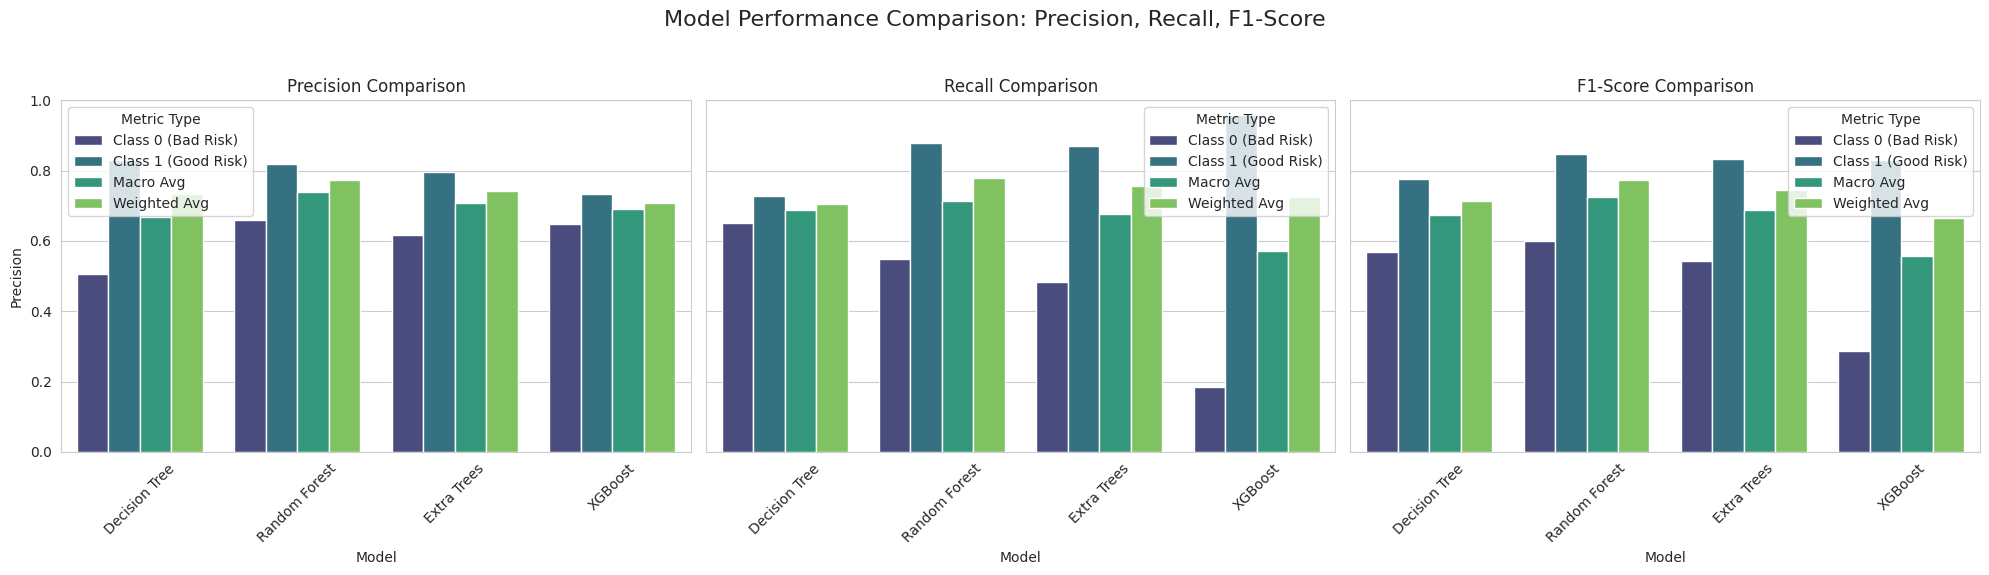

In [109]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle('Model Performance Comparison: Precision, Recall, F1-Score', fontsize=16)

metric_names = ['Precision', 'Recall', 'F1-Score']

for i, metric in enumerate(metric_names):
    sns.barplot(x='Model', y=metric, hue='Metric_Type', data=metrics_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0, 1) # Set y-axis limits from 0 to 1 for better comparison
    axes[i].legend(title='Metric Type')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

### Deciding the Best Model based on Comprehensive Metrics

Considering the precision, recall, and F1-score across both classes (0 for 'bad risk' and 1 for 'good risk'), and also the macro and weighted averages, we can get a more nuanced view of model performance.

From the generated plots and the previously discussed confusion matrices:

1.  **Random Forest** consistently shows strong performance across all metrics. It maintains a good balance between precision and recall for both classes. For 'bad risk' (class 0), it has decent precision (meaning when it predicts 'bad', it's often correct) and recall (meaning it catches a good portion of actual 'bad' risks). For 'good risk' (class 1), its precision and recall are also high.

2.  **XGBoost**, while having excellent recall for 'good risk' (class 1), which means it correctly identifies most 'good' risks, it significantly suffers in precision for 'bad risk' (class 0). This means when XGBoost predicts 'bad risk', it is often wrong (a high number of False Positives), as seen in its confusion matrix where 49 instances of actual 'bad' risk were predicted as 'good'. In credit risk, this is generally undesirable as approving loans for 'bad' risks can be very costly.

3.  **Decision Tree** and **Extra Trees** perform similarly, with Extra Trees generally having slightly better overall metrics than Decision Tree. However, both tend to have lower precision and recall for 'bad risk' (class 0) compared to Random Forest, indicating they are not as effective in identifying and correctly classifying the minority 'bad' class.

**Conclusion:**

If the primary concern is to minimize False Positives (i.e., not incorrectly classify 'bad risk' customers as 'good risk' to avoid financial losses), then **Random Forest** is still the superior choice. It offers the best balance of identifying both 'good' and 'bad' risks effectively, with robust precision and recall for both classes, leading to a higher overall F1-score and accuracy compared to the other models, especially when considering the average metrics.